In [1]:
import numpy as np
import pandas as pd

import scarf
from scarf.plotting import CellField, ColorScale

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
analysis_run = ds.pipeline.open(label="docs_default")
graph = analysis_run["connectivity_map"]

Downloading bucket files: 52931410 / 52931410 complete

Downloading bytes: 52931410 / 52931410 complete

In [2]:
annotations = ds.cells.fetch("clusters", key="I")
source = annotations == "Ductal"
sink = np.isin(annotations, ["Alpha", "Beta", "Delta"])
if not source.any() or not sink.any():
    raise ValueError("Source and sink annotations must both be present")
source_sink_vector = np.zeros(len(annotations), dtype=float)
source_sink_vector[source] = -1.0 / source.sum()
source_sink_vector[sink] = 1.0 / sink.sum()
pseudotime_ref = ds.run_pseudotime_scoring(graph, ss_vec=source_sink_vector)

In [3]:
sink_labels_ref = analysis_run["clusters"]
sink_labels = analysis_run.cells.fetch("clusters")
assert len(annotations) == len(sink_labels)
shares = pd.crosstab(sink_labels, annotations, normalize="index")
sink_table = pd.DataFrame(
    {
        "annotation": shares.idxmax(axis=1),
        "majority share": shares.max(axis=1),
    }
)

In [4]:
candidate_fates = ["Alpha", "Beta", "Delta"]
selected = sink_table.loc[sink_table["annotation"].isin(candidate_fates)]
if (
    len(selected) != len(candidate_fates)
    or selected["annotation"].nunique() != len(candidate_fates)
):
    raise ValueError("Each candidate fate must match exactly one cluster")
selected = (
    selected.reset_index(names="sink label")
    .set_index("annotation")
    .loc[candidate_fates]
)
terminal_labels = selected["sink label"].astype(int).tolist()
sink_names = dict(zip(terminal_labels, candidate_fates, strict=True))
selected

,sink label,majority share
annotation,,
Alpha,3,0.928416
Beta,11,0.977778
Delta,10,0.741935


In [5]:
fate_ref = ds.run_fate_mapping(pseudotime_ref, sink_labels_ref, sinks=terminal_labels)
fate = ds.load_fate_mapping(fate_ref)
int(fate.valid.sum()), len(fate.valid)

(3696, 3696)

In [6]:
probabilities = pd.DataFrame(
    fate.values[fate.valid],
    columns=[sink_names[int(label)] for label in fate.sink_labels],
)
probabilities["row-sum error"] = abs(probabilities.sum(axis=1) - 1.0)
probabilities.agg(["min", "median", "max"])

,Alpha,Beta,Delta,row-sum error
min,0.000000,0.000000,0.000000,0.000000e+00
median,0.360949,0.299733,0.310332,0.000000e+00
max,1.000000,1.000000,1.000000,5.960464e-08


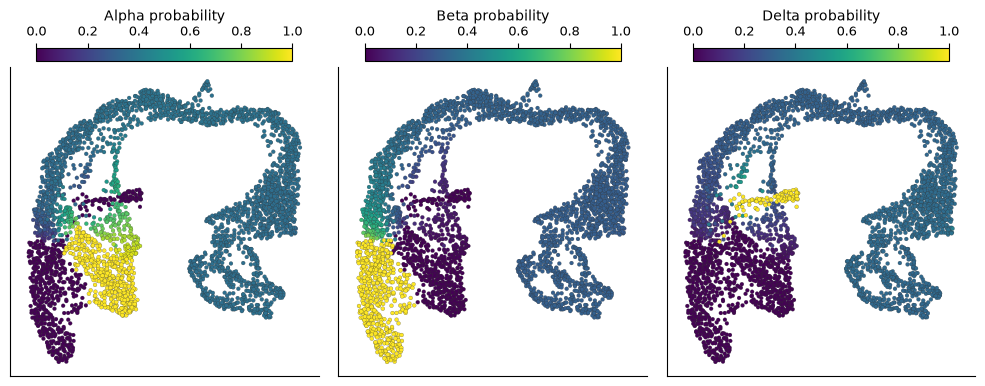

In [7]:
for index, label in enumerate(fate.sink_labels):
    ds.cells.insert(
        f"fate_prob_{sink_names[int(label)]}",
        fate.values[:, index],
        key="I",
        overwrite=True,
    )

ds.plots.embedding(
    layout=analysis_run["umap"],
    color_by=[
        CellField(f"fate_prob_{name}", kind="continuous", label=f"{name} probability")
        for name in candidate_fates
    ],
    n_columns=3,
    color_scale=ColorScale(scope="shared", vmin=0, vmax=1),
    sort_values=True,
)